File downloaded from gs://ycbs299/master_merged_data.csv to /content/fire_incidents_caserne_month_aggregated.csv
Error processing Industrial for Chi-Squared Test: Bin labels must be one fewer than the number of bin edges


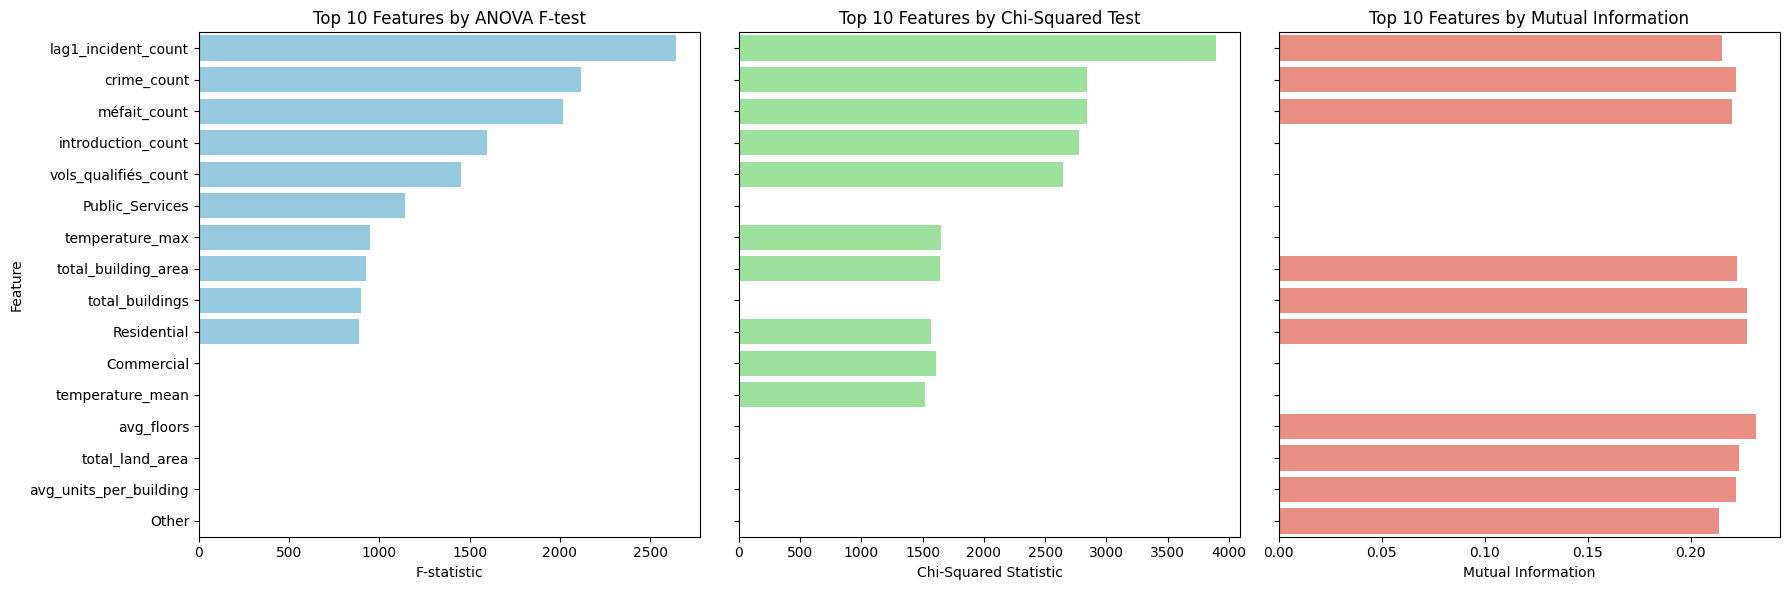


Overlapping Features:
ANOVA & Chi-Squared: {'temperature_max', 'lag1_incident_count', 'total_building_area', 'méfait_count', 'crime_count', 'introduction_count', 'vols_qualifiés_count', 'Residential'}
ANOVA & Mutual Information: {'total_buildings', 'lag1_incident_count', 'total_building_area', 'crime_count', 'méfait_count', 'Residential'}
Chi-Squared & Mutual Information: {'lag1_incident_count', 'total_building_area', 'crime_count', 'méfait_count', 'Residential'}
All Three Methods: {'lag1_incident_count', 'total_building_area', 'méfait_count', 'crime_count', 'Residential'}


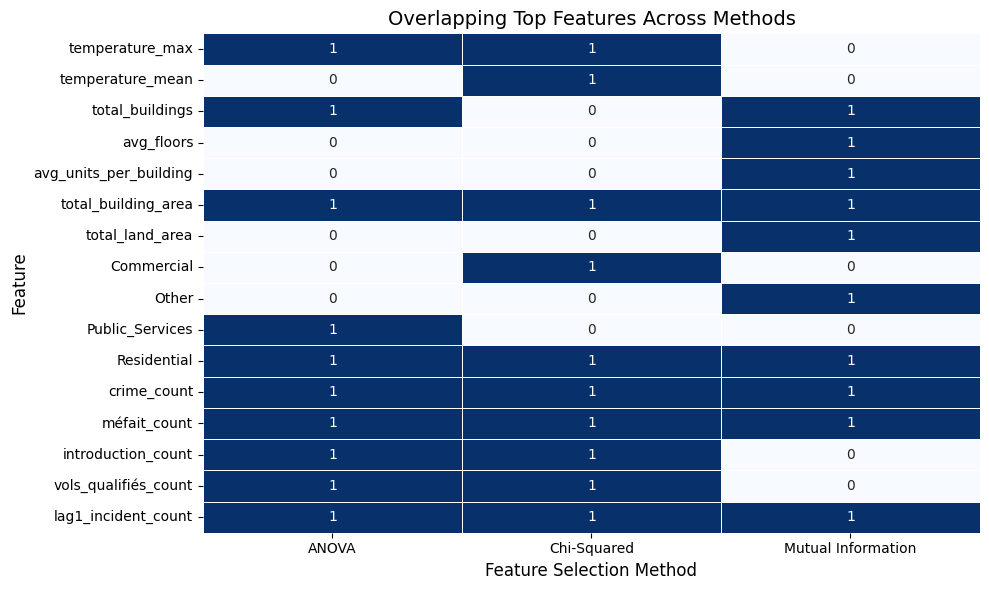

In [3]:
import pandas as pd
import numpy as np
from scipy.stats import f_oneway, chi2_contingency
from sklearn.feature_selection import mutual_info_regression
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.cloud import storage

# Step 1: Set Google Application Credentials
os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = '/content/peppy-web-437616-r6-ec3f12e7c15e.json'

# Step 2: Download the pre-aggregated file from the GCP bucket
bucket_name = 'ycbs299'
blob_name = 'master_merged_data.csv'
local_file_path = '/content/fire_incidents_caserne_month_aggregated.csv'

# Initialize the storage client and download the file
storage_client = storage.Client()
bucket = storage_client.bucket(bucket_name)
blob = bucket.blob(blob_name)
blob.download_to_filename(local_file_path)
print(f"File downloaded from gs://{bucket_name}/{blob_name} to {local_file_path}")

# Step 3: Load the pre-aggregated dataset (caserne-month level)
agg_df = pd.read_csv(local_file_path)
agg_df['risk_level'] = agg_df['risk_level'].astype('category')

# Step 4: Define numeric columns for analysis
numeric_cols = ['temperature_max', 'temperature_min', 'temperature_mean', 'precipitation_sum',
                'wind_speed_max', 'wind_gusts_max', 'total_buildings', 'avg_floors',
                'avg_units_per_building', 'median_construction_year', 'total_building_area',
                'total_land_area', 'Commercial', 'Industrial', 'Infrastructure', 'Other',
                'Public_Services', 'Recreational', 'Residential', 'Vacant_Unused',
                'crime_count', 'méfait_count', 'introduction_count', 'vols_qualifiés_count',
                'hydrant_count', 'population', 'area_square_km', 'lag1_incident_count']

# Step 5: Feature Selection Methods

# ANOVA F-test
anova_results = {}
for feature in numeric_cols:
    groups = [agg_df[feature][agg_df['risk_level'] == level].dropna() for level in agg_df['risk_level'].cat.categories]
    if all(len(g) > 0 for g in groups):
        f_stat, p_value = f_oneway(*groups)
        anova_results[feature] = f_stat
anova_df = pd.DataFrame.from_dict(anova_results, orient='index', columns=['F_statistic']).sort_values(by='F_statistic', ascending=False).head(10)

# Chi-Squared Test (bin features into tertiles, handle duplicates)
chi2_results = {}
for feature in numeric_cols:
    try:
        # Check the number of unique values in the feature
        unique_values = agg_df[feature].nunique()
        if unique_values < 3:
            # Use pd.cut for features with fewer than 3 unique values (equal intervals)
            agg_df[f'{feature}_binned'] = pd.cut(agg_df[feature], bins=3, labels=['Low', 'Medium', 'High'], include_lowest=True)
        else:
            # Use pd.qcut for features with enough unique values (quantiles)
            agg_df[f'{feature}_binned'] = pd.qcut(agg_df[feature], q=3, labels=['Low', 'Medium', 'High'], duplicates='drop')

        # Create a contingency table
        contingency_table = pd.crosstab(agg_df[f'{feature}_binned'], agg_df['risk_level'])
        # Ensure the contingency table is not empty
        if contingency_table.size > 0:
            chi2_stat, p_value, _, _ = chi2_contingency(contingency_table)
            chi2_results[feature] = chi2_stat
        else:
            chi2_results[feature] = 0
    except Exception as e:
        print(f"Error processing {feature} for Chi-Squared Test: {e}")
        chi2_results[feature] = 0

chi2_df = pd.DataFrame.from_dict(chi2_results, orient='index', columns=['Chi2_statistic']).sort_values(by='Chi2_statistic', ascending=False).head(10)

# Mutual Information (with incident_count)
mi_scores = mutual_info_regression(agg_df[numeric_cols].fillna(0), agg_df['incident_count'])
mi_df = pd.DataFrame({'Feature': numeric_cols, 'Mutual_Information': mi_scores}).sort_values(by='Mutual_Information', ascending=False).head(10)

# Step 6: Visualizations for Feature Selection

# Plot 1: Bar Plots for Top 10 Features by Each Method (Side by Side)
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# ANOVA F-test
sns.barplot(x='F_statistic', y=anova_df.index, data=anova_df, ax=axes[0], color='skyblue')
axes[0].set_title('Top 10 Features by ANOVA F-test', fontsize=12)
axes[0].set_xlabel('F-statistic', fontsize=10)
axes[0].set_ylabel('Feature', fontsize=10)

# Chi-Squared Test
sns.barplot(x='Chi2_statistic', y=chi2_df.index, data=chi2_df, ax=axes[1], color='lightgreen')
axes[1].set_title('Top 10 Features by Chi-Squared Test', fontsize=12)
axes[1].set_xlabel('Chi-Squared Statistic', fontsize=10)
axes[1].set_ylabel('')

# Mutual Information
sns.barplot(x='Mutual_Information', y='Feature', data=mi_df, ax=axes[2], color='salmon')
axes[2].set_title('Top 10 Features by Mutual Information', fontsize=12)
axes[2].set_xlabel('Mutual Information', fontsize=10)
axes[2].set_ylabel('')

plt.tight_layout()
plt.savefig('/content/feature_selection_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Overlapping Features (Comparison)
# Get top 10 features from each method
top_features_anova = set(anova_df.index)
top_features_chi2 = set(chi2_df.index)
top_features_mi = set(mi_df['Feature'])

# Find overlapping features
overlap_anova_chi2 = top_features_anova.intersection(top_features_chi2)
overlap_anova_mi = top_features_anova.intersection(top_features_mi)
overlap_chi2_mi = top_features_chi2.intersection(top_features_mi)
overlap_all = top_features_anova.intersection(top_features_chi2).intersection(top_features_mi)

print("\nOverlapping Features:")
print(f"ANOVA & Chi-Squared: {overlap_anova_chi2}")
print(f"ANOVA & Mutual Information: {overlap_anova_mi}")
print(f"Chi-Squared & Mutual Information: {overlap_chi2_mi}")
print(f"All Three Methods: {overlap_all}")

# Create a DataFrame for overlapping features
overlap_df = pd.DataFrame(index=numeric_cols)
overlap_df['ANOVA'] = overlap_df.index.isin(top_features_anova).astype(int)
overlap_df['Chi-Squared'] = overlap_df.index.isin(top_features_chi2).astype(int)
overlap_df['Mutual Information'] = overlap_df.index.isin(top_features_mi).astype(int)
overlap_df = overlap_df[overlap_df.sum(axis=1) > 0]  # Keep only features in at least one top 10

# Plot a heatmap to show overlapping features
plt.figure(figsize=(10, 6))
sns.heatmap(overlap_df, cmap='Blues', annot=True, cbar=False, linewidths=0.5)
plt.title('Overlapping Top Features Across Methods', fontsize=14)
plt.xlabel('Feature Selection Method', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.savefig('/content/feature_selection_overlap.png', dpi=300, bbox_inches='tight')
plt.show()


